In [1]:
from langgraph.graph import START,StateGraph,END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict,Annotated
from langgraph.types import Command, interrupt
import operator

In [2]:
class HiringState(TypedDict):
    candidate_name: str
    resume: str
    job_description: str
    resume_score: int
    
    skill_match_score: int
    skill_match_reason : str

    hr_decision: dict

    interview_questions: list[str]

    final_status: str
    final_message:str

In [3]:
from langchain_openai import ChatOpenAI
# instance the LLM
api_key = input("Enter API Key: ")
base_url = input("Enter Base URL: ")


llm = ChatOpenAI(
    model="gpt-5.4-mini",
    api_key= api_key,
    base_url=base_url
)

In [4]:
from pydantic import BaseModel

class ResumeScore(BaseModel):
    score: int
    reason: str

In [5]:
#Node 1

def resume_analyser(state:HiringState):
    print("-"*10,"Analysing Your resume.....","-"*10)

    resume = state["resume"]

    structured = llm.with_structured_output(ResumeScore)
    
    response = structured.invoke(f"Analyze this resume and give a score out of 100.\n\nResume:\n{resume}")
    
    print(f"\n\nYour Resume Score :{response.score}\n\n")
    return {
        "resume_score":response.score
    }
    

In [6]:
class SkillMatchScore(BaseModel):
    score:int
    reason:list[str]

In [7]:
# Node 2

def skill_match_agent(state:HiringState):
    print("-"*10,"Skill Set Matching Now.....","-"*10)
    resume = state["resume"]
    job_description = state["job_description"]
    skills_structured = llm.with_structured_output(SkillMatchScore)
    
    response = skills_structured.invoke(
        f"""
            Compare the resume with the job description. 
            Give: 1. Skill match score out of 100 
            2. Reason for the score 
            Resume: {resume} 
            Job Description: {job_description}
        """
    )
    print(f"\n\nYour Skill Match Score is :{response.score}\n\n")

    return { 
            "skill_match_score": response.score, 
            "skill_match_reason": response.reason 
    }
    # print(response)
    # print(type(response))


In [8]:
def router(state:HiringState):
    
    score = state["skill_match_score"]
    if(score<50):
        return "reject"
    return "hr_review"

In [9]:
def human_review(state:HiringState):
    print("----- Checking in Progess ------")
    
    decision = interrupt("Approve Candidate ?")
    
    print(f"\n\nStatus of Application is {decision["approved"]}\n\n")
    
    return {
        "hr_decision":decision
    }
    

In [10]:
class questions(BaseModel):
    questions:list[str]

In [11]:
def interview_question_generator(state:HiringState):
        
    structured_llm = llm.with_structured_output(questions)
        
    response = structured_llm.invoke(f"Give me 5 Techincal and 3 behavioural questions based on the resume {state["resume"]}")
    
    print("-"*10,"Answer the following questions","-"*10,"\n\n")
    
    questions_list = response.questions
    for i in range(len(questions_list)):
        print(f"{i+1}.",questions_list[i])
    
    
    return {
        "interview_questions":questions_list
    }        
    

In [12]:
def final_decision(state:HiringState):
    resume_score = state["resume_score"]
    skill_match_agent = state["skill_match_score"]
    hr_approval = state["hr_decision"]["approved"]
    
    if(resume_score>60 and skill_match_agent>60 and hr_approval):
        return{
            "final_status": "Selected", 
            "final_message": ( "Congratulations! The candidate has successfully cleared " 
                              "resume screening, skill evaluation, and HR review. " 
                              "Proceed to the interview process." )
        }
    return{
        "final_status": "Rejected", 
        "final_message": ( "The candidate did not meet the hiring criteria based on " "resume analysis, skill matching, or HR review." )
    }

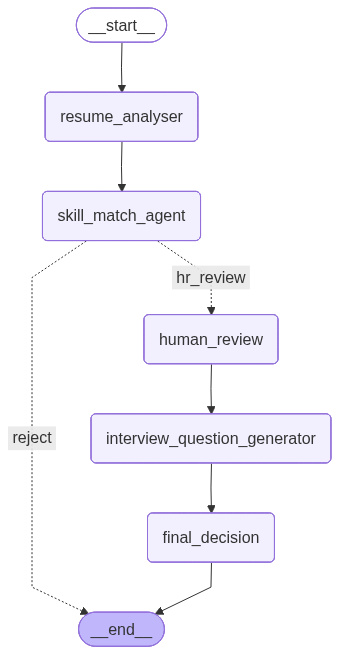

In [13]:
builder = StateGraph(HiringState)

builder.add_node("resume_analyser",resume_analyser)
builder.add_node('skill_match_agent',skill_match_agent)
builder.add_node("human_review",human_review)
builder.add_node("interview_question_generator",interview_question_generator)
builder.add_node("final_decision",final_decision)

builder.add_edge(START,"resume_analyser")
builder.add_edge("resume_analyser","skill_match_agent")

builder.add_conditional_edges(
    "skill_match_agent",
    router,
    {
        "reject":END,
        "hr_review":"human_review"
    }
)

builder.add_edge("human_review","interview_question_generator")
builder.add_edge("interview_question_generator","final_decision")
builder.add_edge("final_decision",END)

memory = InMemorySaver()

graph = builder.compile(
    checkpointer=memory
)
graph

In [14]:
config = {
    "configurable":{"thread_id":"1"}
}

In [15]:
graph.invoke({
    "candidate_name": "Yeswanth Reddy",
    "resume": """
        B.Tech Computer Science student with experience in Python,
        Java, Spring Boot, LangChain, LangGraph, SQL, and Machine Learning.

        Projects:
        - Animal Detection System using TensorFlow and OpenCV
        - AI Research Assistant using LangChain and FAISS
        - Toll Plaza Finder using Spring Boot

        Internship:
        - Full Stack Intern at IamNeo

        Skills:
        Python, Java, Spring Boot, SQL, LangChain,
        LangGraph, Machine Learning, Git, REST APIs
    """,

    "job_description": """
        Looking for a Software Engineer with experience in Python,
        Java, REST APIs, SQL, Git, and AI frameworks.

        Preferred Skills:
        - LangChain
        - Spring Boot
        - Machine Learning

        Responsibilities:
        - Build backend services
        - Work with AI applications
        - Develop scalable APIs
    """

    },config = config
)

---------- Analysing Your resume..... ----------


Your Resume Score :68


---------- Skill Set Matching Now..... ----------


Your Skill Match Score is :92


----- Checking in Progess ------


{'candidate_name': 'Yeswanth Reddy',
 'resume': '\n        B.Tech Computer Science student with experience in Python,\n        Java, Spring Boot, LangChain, LangGraph, SQL, and Machine Learning.\n\n        Projects:\n        - Animal Detection System using TensorFlow and OpenCV\n        - AI Research Assistant using LangChain and FAISS\n        - Toll Plaza Finder using Spring Boot\n\n        Internship:\n        - Full Stack Intern at IamNeo\n\n        Skills:\n        Python, Java, Spring Boot, SQL, LangChain,\n        LangGraph, Machine Learning, Git, REST APIs\n    ',
 'job_description': '\n        Looking for a Software Engineer with experience in Python,\n        Java, REST APIs, SQL, Git, and AI frameworks.\n\n        Preferred Skills:\n        - LangChain\n        - Spring Boot\n        - Machine Learning\n\n        Responsibilities:\n        - Build backend services\n        - Work with AI applications\n        - Develop scalable APIs\n    ',
 'resume_score': 68,
 'skill_match

In [16]:
final_response = graph.invoke(Command(
    resume={
            "approved": True,
            "reviewer": "HR Manager",
            "comments": "Strong candidate"
        }),config= config)

----- Checking in Progess ------


Status of Application is True


---------- Answer the following questions ---------- 


1. Can you explain how you designed and implemented the Animal Detection System using TensorFlow and OpenCV? What challenges did you face with model accuracy or real-time detection?
2. How does your AI Research Assistant use LangChain and FAISS together? Walk me through the retrieval pipeline and how you optimized search relevance.
3. In your Toll Plaza Finder project, how did you structure the Spring Boot application, and how did you handle REST API design and database interactions?
4. What is the difference between LangChain and LangGraph, and in what scenarios would you choose one over the other?
5. How would you optimize a Python or Java-based backend service for better performance when handling multiple API requests and SQL queries?
6. Tell me about a time you worked on a project with tight deadlines. How did you prioritize tasks and ensure delivery?
7. Descri

In [17]:
final_response

{'candidate_name': 'Yeswanth Reddy',
 'resume': '\n        B.Tech Computer Science student with experience in Python,\n        Java, Spring Boot, LangChain, LangGraph, SQL, and Machine Learning.\n\n        Projects:\n        - Animal Detection System using TensorFlow and OpenCV\n        - AI Research Assistant using LangChain and FAISS\n        - Toll Plaza Finder using Spring Boot\n\n        Internship:\n        - Full Stack Intern at IamNeo\n\n        Skills:\n        Python, Java, Spring Boot, SQL, LangChain,\n        LangGraph, Machine Learning, Git, REST APIs\n    ',
 'job_description': '\n        Looking for a Software Engineer with experience in Python,\n        Java, REST APIs, SQL, Git, and AI frameworks.\n\n        Preferred Skills:\n        - LangChain\n        - Spring Boot\n        - Machine Learning\n\n        Responsibilities:\n        - Build backend services\n        - Work with AI applications\n        - Develop scalable APIs\n    ',
 'resume_score': 68,
 'skill_match

In [18]:
from rich import print

In [19]:
snapshot = graph.get_state(config)
print(snapshot.values)

{
    'candidate_name': 'Yeswanth Reddy',
    'resume': '\n        B.Tech Computer Science student with experience in Python,\n        Java, Spring Boot, 
LangChain, LangGraph, SQL, and Machine Learning.\n\n        Projects:\n        - Animal Detection System using 
TensorFlow and OpenCV\n        - AI Research Assistant using LangChain and FAISS\n        - Toll Plaza Finder using
Spring Boot\n\n        Internship:\n        - Full Stack Intern at IamNeo\n\n        Skills:\n        Python, Java,
Spring Boot, SQL, LangChain,\n        LangGraph, Machine Learning, Git, REST APIs\n    ',
    'job_description': '\n        Looking for a Software Engineer with experience in Python,\n        Java, REST 
APIs, SQL, Git, and AI frameworks.\n\n        Preferred Skills:\n        - LangChain\n        - Spring Boot\n      
- Machine Learning\n\n        Responsibilities:\n        - Build backend services\n        - Work with AI 
applications\n        - Develop scalable APIs\n    ',
    'resume_score': 68,
    'skill_match_score': 92,
    'skill_match_reason': [
        'Strong overlap with the core required skills: Python, Java, REST APIs, SQL, and Git are all explicitly 
listed on the resume.',
        'Preferred skills also match well: LangChain, Spring Boot, and Machine Learning are present.',
        'Projects demonstrate relevant applied experience in AI applications and backend development, including an 
AI Research Assistant with LangChain/FAISS and a Toll Plaza Finder using Spring Boot.',
        'The internship as a Full Stack Intern suggests practical software engineering exposure.',
        'Minor gaps: the resume does not explicitly mention production-scale backend service ownership, 
scalability, or broader AI framework depth beyond LangChain/LangGraph and project work.'
    ],
    'hr_decision': {'approved': True, 'reviewer': 'HR Manager', 'comments': 'Strong candidate'},
    'interview_questions': [
        'Can you explain how you designed and implemented the Animal Detection System using TensorFlow and OpenCV? 
What challenges did you face with model accuracy or real-time detection?',
        'How does your AI Research Assistant use LangChain and FAISS together? Walk me through the retrieval 
pipeline and how you optimized search relevance.',
        'In your Toll Plaza Finder project, how did you structure the Spring Boot application, and how did you 
handle REST API design and database interactions?',
        'What is the difference between LangChain and LangGraph, and in what scenarios would you choose one over 
the other?',
        'How would you optimize a Python or Java-based backend service for better performance when handling 
multiple API requests and SQL queries?',
        'Tell me about a time you worked on a project with tight deadlines. How did you prioritize tasks and ensure
delivery?',
        'Describe a situation during your internship at IamNeo where you had to learn a new tool or framework 
quickly. How did you approach it?',
        'Tell me about a time you faced a technical bug or failure in one of your projects. How did you debug it, 
and what did you learn?'
    ],
    'final_status': 'Selected',
    'final_message': 'Congratulations! The candidate has successfully cleared resume screening, skill evaluation, 
and HR review. Proceed to the interview process.'
}

In [20]:
history = list(graph.get_state_history(config))

for h in history:
    print(h)

StateSnapshot(
    values={
        'candidate_name': 'Yeswanth Reddy',
        'resume': '\n        B.Tech Computer Science student with experience in Python,\n        Java, Spring Boot,
LangChain, LangGraph, SQL, and Machine Learning.\n\n        Projects:\n        - Animal Detection System using 
TensorFlow and OpenCV\n        - AI Research Assistant using LangChain and FAISS\n        - Toll Plaza Finder using
Spring Boot\n\n        Internship:\n        - Full Stack Intern at IamNeo\n\n        Skills:\n        Python, Java,
Spring Boot, SQL, LangChain,\n        LangGraph, Machine Learning, Git, REST APIs\n    ',
        'job_description': '\n        Looking for a Software Engineer with experience in Python,\n        Java, 
REST APIs, SQL, Git, and AI frameworks.\n\n        Preferred Skills:\n        - LangChain\n        - Spring Boot\n 
- Machine Learning\n\n        Responsibilities:\n        - Build backend services\n        - Work with AI 
applications\n        - Develop scalable APIs\n    ',
        'resume_score': 68,
        'skill_match_score': 92,
        'skill_match_reason': [
            'Strong overlap with the core required skills: Python, Java, REST APIs, SQL, and Git are all explicitly
listed on the resume.',
            'Preferred skills also match well: LangChain, Spring Boot, and Machine Learning are present.',
            'Projects demonstrate relevant applied experience in AI applications and backend development, including
an AI Research Assistant with LangChain/FAISS and a Toll Plaza Finder using Spring Boot.',
            'The internship as a Full Stack Intern suggests practical software engineering exposure.',
            'Minor gaps: the resume does not explicitly mention production-scale backend service ownership, 
scalability, or broader AI framework depth beyond LangChain/LangGraph and project work.'
        ],
        'hr_decision': {'approved': True, 'reviewer': 'HR Manager', 'comments': 'Strong candidate'},
        'interview_questions': [
            'Can you explain how you designed and implemented the Animal Detection System using TensorFlow and 
OpenCV? What challenges did you face with model accuracy or real-time detection?',
            'How does your AI Research Assistant use LangChain and FAISS together? Walk me through the retrieval 
pipeline and how you optimized search relevance.',
            'In your Toll Plaza Finder project, how did you structure the Spring Boot application, and how did you 
handle REST API design and database interactions?',
            'What is the difference between LangChain and LangGraph, and in what scenarios would you choose one 
over the other?',
            'How would you optimize a Python or Java-based backend service for better performance when handling 
multiple API requests and SQL queries?',
            'Tell me about a time you worked on a project with tight deadlines. How did you prioritize tasks and 
ensure delivery?',
            'Describe a situation during your internship at IamNeo where you had to learn a new tool or framework 
quickly. How did you approach it?',
            'Tell me about a time you faced a technical bug or failure in one of your projects. How did you debug 
it, and what did you learn?'
        ],
        'final_status': 'Selected',
        'final_message': 'Congratulations! The candidate has successfully cleared resume screening, skill 
evaluation, and HR review. Proceed to the interview process.'
    },
    next=(),
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e10-32b4-6957-8005-df882187eade'
        }
    },
    metadata={'source': 'loop', 'step': 5, 'parents': {}},
    created_at='2026-06-27T04:31:05.994442+00:00',
    parent_config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e10-32b0-6821-8004-1b2f991a2e20'
        }
    },
    tasks=(),
    interrupt

StateSnapshot(
    values={
        'candidate_name': 'Yeswanth Reddy',
        'resume': '\n        B.Tech Computer Science student with experience in Python,\n        Java, Spring Boot,
LangChain, LangGraph, SQL, and Machine Learning.\n\n        Projects:\n        - Animal Detection System using 
TensorFlow and OpenCV\n        - AI Research Assistant using LangChain and FAISS\n        - Toll Plaza Finder using
Spring Boot\n\n        Internship:\n        - Full Stack Intern at IamNeo\n\n        Skills:\n        Python, Java,
Spring Boot, SQL, LangChain,\n        LangGraph, Machine Learning, Git, REST APIs\n    ',
        'job_description': '\n        Looking for a Software Engineer with experience in Python,\n        Java, 
REST APIs, SQL, Git, and AI frameworks.\n\n        Preferred Skills:\n        - LangChain\n        - Spring Boot\n 
- Machine Learning\n\n        Responsibilities:\n        - Build backend services\n        - Work with AI 
applications\n        - Develop scalable APIs\n    ',
        'resume_score': 68,
        'skill_match_score': 92,
        'skill_match_reason': [
            'Strong overlap with the core required skills: Python, Java, REST APIs, SQL, and Git are all explicitly
listed on the resume.',
            'Preferred skills also match well: LangChain, Spring Boot, and Machine Learning are present.',
            'Projects demonstrate relevant applied experience in AI applications and backend development, including
an AI Research Assistant with LangChain/FAISS and a Toll Plaza Finder using Spring Boot.',
            'The internship as a Full Stack Intern suggests practical software engineering exposure.',
            'Minor gaps: the resume does not explicitly mention production-scale backend service ownership, 
scalability, or broader AI framework depth beyond LangChain/LangGraph and project work.'
        ],
        'hr_decision': {'approved': True, 'reviewer': 'HR Manager', 'comments': 'Strong candidate'},
        'interview_questions': [
            'Can you explain how you designed and implemented the Animal Detection System using TensorFlow and 
OpenCV? What challenges did you face with model accuracy or real-time detection?',
            'How does your AI Research Assistant use LangChain and FAISS together? Walk me through the retrieval 
pipeline and how you optimized search relevance.',
            'In your Toll Plaza Finder project, how did you structure the Spring Boot application, and how did you 
handle REST API design and database interactions?',
            'What is the difference between LangChain and LangGraph, and in what scenarios would you choose one 
over the other?',
            'How would you optimize a Python or Java-based backend service for better performance when handling 
multiple API requests and SQL queries?',
            'Tell me about a time you worked on a project with tight deadlines. How did you prioritize tasks and 
ensure delivery?',
            'Describe a situation during your internship at IamNeo where you had to learn a new tool or framework 
quickly. How did you approach it?',
            'Tell me about a time you faced a technical bug or failure in one of your projects. How did you debug 
it, and what did you learn?'
        ]
    },
    next=('final_decision',),
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e10-32b0-6821-8004-1b2f991a2e20'
        }
    },
    metadata={'source': 'loop', 'step': 4, 'parents': {}},
    created_at='2026-06-27T04:31:05.992783+00:00',
    parent_config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e10-0a46-6c36-8003-21738c472f7b'
        }
    },
    tasks=(
        PregelTask(
            id='badf5504-19fb-e3a3-f39b-dd7307214f71',
            name='final_decision',
            path=('__pregel_pull', 'final_decision'),
            error=None,
            inte

StateSnapshot(
    values={
        'candidate_name': 'Yeswanth Reddy',
        'resume': '\n        B.Tech Computer Science student with experience in Python,\n        Java, Spring Boot,
LangChain, LangGraph, SQL, and Machine Learning.\n\n        Projects:\n        - Animal Detection System using 
TensorFlow and OpenCV\n        - AI Research Assistant using LangChain and FAISS\n        - Toll Plaza Finder using
Spring Boot\n\n        Internship:\n        - Full Stack Intern at IamNeo\n\n        Skills:\n        Python, Java,
Spring Boot, SQL, LangChain,\n        LangGraph, Machine Learning, Git, REST APIs\n    ',
        'job_description': '\n        Looking for a Software Engineer with experience in Python,\n        Java, 
REST APIs, SQL, Git, and AI frameworks.\n\n        Preferred Skills:\n        - LangChain\n        - Spring Boot\n 
- Machine Learning\n\n        Responsibilities:\n        - Build backend services\n        - Work with AI 
applications\n        - Develop scalable APIs\n    ',
        'resume_score': 68,
        'skill_match_score': 92,
        'skill_match_reason': [
            'Strong overlap with the core required skills: Python, Java, REST APIs, SQL, and Git are all explicitly
listed on the resume.',
            'Preferred skills also match well: LangChain, Spring Boot, and Machine Learning are present.',
            'Projects demonstrate relevant applied experience in AI applications and backend development, including
an AI Research Assistant with LangChain/FAISS and a Toll Plaza Finder using Spring Boot.',
            'The internship as a Full Stack Intern suggests practical software engineering exposure.',
            'Minor gaps: the resume does not explicitly mention production-scale backend service ownership, 
scalability, or broader AI framework depth beyond LangChain/LangGraph and project work.'
        ],
        'hr_decision': {'approved': True, 'reviewer': 'HR Manager', 'comments': 'Strong candidate'}
    },
    next=('interview_question_generator',),
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e10-0a46-6c36-8003-21738c472f7b'
        }
    },
    metadata={'source': 'loop', 'step': 3, 'parents': {}},
    created_at='2026-06-27T04:31:01.755153+00:00',
    parent_config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e10-0a0b-6560-8002-9b38302a59e0'
        }
    },
    tasks=(
        PregelTask(
            id='36338921-0ca0-555b-0e17-20aa53d7c731',
            name='interview_question_generator',
            path=('__pregel_pull', 'interview_question_generator'),
            error=None,
            interrupts=(),
            state=None,
            result={
                'interview_questions': [
                    'Can you explain how you designed and implemented the Animal Detection System using TensorFlow 
and OpenCV? What challenges did you face with model accuracy or real-time detection?',
                    'How does your AI Research Assistant use LangChain and FAISS together? Walk me through the 
retrieval pipeline and how you optimized search relevance.',
                    'In your Toll Plaza Finder project, how did you structure the Spring Boot application, and how 
did you handle REST API design and database interactions?',
                    'What is the difference between LangChain and LangGraph, and in what scenarios would you choose
one over the other?',
                    'How would you optimize a Python or Java-based backend service for better performance when 
handling multiple API requests and SQL queries?',
                    'Tell me about a time you worked on a project with tight deadlines. How did you prioritize 
tasks and ensure delivery?',
                    'Describe a situation during your internship at IamNeo where you had to learn a new tool or 
framework quickly. How did you approach 

StateSnapshot(
    values={
        'candidate_name': 'Yeswanth Reddy',
        'resume': '\n        B.Tech Computer Science student with experience in Python,\n        Java, Spring Boot,
LangChain, LangGraph, SQL, and Machine Learning.\n\n        Projects:\n        - Animal Detection System using 
TensorFlow and OpenCV\n        - AI Research Assistant using LangChain and FAISS\n        - Toll Plaza Finder using
Spring Boot\n\n        Internship:\n        - Full Stack Intern at IamNeo\n\n        Skills:\n        Python, Java,
Spring Boot, SQL, LangChain,\n        LangGraph, Machine Learning, Git, REST APIs\n    ',
        'job_description': '\n        Looking for a Software Engineer with experience in Python,\n        Java, 
REST APIs, SQL, Git, and AI frameworks.\n\n        Preferred Skills:\n        - LangChain\n        - Spring Boot\n 
- Machine Learning\n\n        Responsibilities:\n        - Build backend services\n        - Work with AI 
applications\n        - Develop scalable APIs\n    ',
        'resume_score': 68,
        'skill_match_score': 92,
        'skill_match_reason': [
            'Strong overlap with the core required skills: Python, Java, REST APIs, SQL, and Git are all explicitly
listed on the resume.',
            'Preferred skills also match well: LangChain, Spring Boot, and Machine Learning are present.',
            'Projects demonstrate relevant applied experience in AI applications and backend development, including
an AI Research Assistant with LangChain/FAISS and a Toll Plaza Finder using Spring Boot.',
            'The internship as a Full Stack Intern suggests practical software engineering exposure.',
            'Minor gaps: the resume does not explicitly mention production-scale backend service ownership, 
scalability, or broader AI framework depth beyond LangChain/LangGraph and project work.'
        ]
    },
    next=('human_review',),
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e10-0a0b-6560-8002-9b38302a59e0'
        }
    },
    metadata={'source': 'loop', 'step': 2, 'parents': {}},
    created_at='2026-06-27T04:31:01.730816+00:00',
    parent_config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e0f-f1dd-61f3-8001-dcf86830cbc6'
        }
    },
    tasks=(
        PregelTask(
            id='3656e7c7-2350-9895-89dc-37d1700544de',
            name='human_review',
            path=('__pregel_pull', 'human_review'),
            error=None,
            interrupts=(Interrupt(value='Approve Candidate ?', id='52ec071b18c416d2281184de6b6d410b'),),
            state=None,
            result={'hr_decision': {'approved': True, 'reviewer': 'HR Manager', 'comments': 'Strong candidate'}}
        ),
    ),
    interrupts=(Interrupt(value='Approve Candidate ?', id='52ec071b18c416d2281184de6b6d410b'),)
)

StateSnapshot(
    values={
        'candidate_name': 'Yeswanth Reddy',
        'resume': '\n        B.Tech Computer Science student with experience in Python,\n        Java, Spring Boot,
LangChain, LangGraph, SQL, and Machine Learning.\n\n        Projects:\n        - Animal Detection System using 
TensorFlow and OpenCV\n        - AI Research Assistant using LangChain and FAISS\n        - Toll Plaza Finder using
Spring Boot\n\n        Internship:\n        - Full Stack Intern at IamNeo\n\n        Skills:\n        Python, Java,
Spring Boot, SQL, LangChain,\n        LangGraph, Machine Learning, Git, REST APIs\n    ',
        'job_description': '\n        Looking for a Software Engineer with experience in Python,\n        Java, 
REST APIs, SQL, Git, and AI frameworks.\n\n        Preferred Skills:\n        - LangChain\n        - Spring Boot\n 
- Machine Learning\n\n        Responsibilities:\n        - Build backend services\n        - Work with AI 
applications\n        - Develop scalable APIs\n    ',
        'resume_score': 68
    },
    next=('skill_match_agent',),
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e0f-f1dd-61f3-8001-dcf86830cbc6'
        }
    },
    metadata={'source': 'loop', 'step': 1, 'parents': {}},
    created_at='2026-06-27T04:30:59.195319+00:00',
    parent_config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e0f-cc68-6510-8000-2b80fb8d9f3b'
        }
    },
    tasks=(
        PregelTask(
            id='a1d58544-46c1-2ad3-84e0-594b0b7c2b9e',
            name='skill_match_agent',
            path=('__pregel_pull', 'skill_match_agent'),
            error=None,
            interrupts=(),
            state=None,
            result={
                'skill_match_score': 92,
                'skill_match_reason': [
                    'Strong overlap with the core required skills: Python, Java, REST APIs, SQL, and Git are all 
explicitly listed on the resume.',
                    'Preferred skills also match well: LangChain, Spring Boot, and Machine Learning are present.',
                    'Projects demonstrate relevant applied experience in AI applications and backend development, 
including an AI Research Assistant with LangChain/FAISS and a Toll Plaza Finder using Spring Boot.',
                    'The internship as a Full Stack Intern suggests practical software engineering exposure.',
                    'Minor gaps: the resume does not explicitly mention production-scale backend service ownership,
scalability, or broader AI framework depth beyond LangChain/LangGraph and project work.'
                ]
            }
        ),
    ),
    interrupts=()
)

StateSnapshot(
    values={
        'candidate_name': 'Yeswanth Reddy',
        'resume': '\n        B.Tech Computer Science student with experience in Python,\n        Java, Spring Boot,
LangChain, LangGraph, SQL, and Machine Learning.\n\n        Projects:\n        - Animal Detection System using 
TensorFlow and OpenCV\n        - AI Research Assistant using LangChain and FAISS\n        - Toll Plaza Finder using
Spring Boot\n\n        Internship:\n        - Full Stack Intern at IamNeo\n\n        Skills:\n        Python, Java,
Spring Boot, SQL, LangChain,\n        LangGraph, Machine Learning, Git, REST APIs\n    ',
        'job_description': '\n        Looking for a Software Engineer with experience in Python,\n        Java, 
REST APIs, SQL, Git, and AI frameworks.\n\n        Preferred Skills:\n        - LangChain\n        - Spring Boot\n 
- Machine Learning\n\n        Responsibilities:\n        - Build backend services\n        - Work with AI 
applications\n        - Develop scalable APIs\n    '
    },
    next=('resume_analyser',),
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e0f-cc68-6510-8000-2b80fb8d9f3b'
        }
    },
    metadata={'source': 'loop', 'step': 0, 'parents': {}},
    created_at='2026-06-27T04:30:55.267697+00:00',
    parent_config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e0f-cc5f-6dbc-bfff-5d5e5617e8e5'
        }
    },
    tasks=(
        PregelTask(
            id='203b0d48-132b-2133-67d8-05b536b02d4f',
            name='resume_analyser',
            path=('__pregel_pull', 'resume_analyser'),
            error=None,
            interrupts=(),
            state=None,
            result={'resume_score': 68}
        ),
    ),
    interrupts=()
)

StateSnapshot(
    values={},
    next=('__start__',),
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f171e0f-cc5f-6dbc-bfff-5d5e5617e8e5'
        }
    },
    metadata={'source': 'input', 'step': -1, 'parents': {}},
    created_at='2026-06-27T04:30:55.264287+00:00',
    parent_config=None,
    tasks=(
        PregelTask(
            id='65ab016a-cc52-2c2b-d74a-d03677ab39ee',
            name='__start__',
            path=('__pregel_pull', '__start__'),
            error=None,
            interrupts=(),
            state=None,
            result={
                'candidate_name': 'Yeswanth Reddy',
                'resume': '\n        B.Tech Computer Science student with experience in Python,\n        Java, 
Spring Boot, LangChain, LangGraph, SQL, and Machine Learning.\n\n        Projects:\n        - Animal Detection 
System using TensorFlow and OpenCV\n        - AI Research Assistant using LangChain and FAISS\n        - Toll Plaza
Finder using Spring Boot\n\n        Internship:\n        - Full Stack Intern at IamNeo\n\n        Skills:\n        
Python, Java, Spring Boot, SQL, LangChain,\n        LangGraph, Machine Learning, Git, REST APIs\n    ',
                'job_description': '\n        Looking for a Software Engineer with experience in Python,\n        
Java, REST APIs, SQL, Git, and AI frameworks.\n\n        Preferred Skills:\n        - LangChain\n        - Spring 
Boot\n        - Machine Learning\n\n        Responsibilities:\n        - Build backend services\n        - Work 
with AI applications\n        - Develop scalable APIs\n    '
            }
        ),
    ),
    interrupts=()
)